# Árbol de Decisión para Regresión

Un **Árbol de Decisión para Regresión** es un modelo no lineal que divide el espacio de entrada en regiones y asigna una predicción numérica a cada una de ellas.

A diferencia de la regresión lineal, este modelo puede capturar relaciones más complejas entre las variables.

El árbol aprende reglas del tipo:

- si \($x_1 < c_1$\)
- si \($x_2 < c_2$\)

y va particionando los datos hasta encontrar grupos más homogéneos respecto al valor objetivo.

Es útil cuando la relación entre variables no es lineal y cuando se desea un modelo flexible y fácil de interpretar visualmente.

In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Importando módulo propio
from utils.regression_functions import *

## Funciones auxiliares

In [3]:
def evaluate_regression_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    return metrics

In [4]:
def train_and_evaluate_decision_tree_regression(
    data_file,
    test_size=0.2,
    random_seed=42,
    plot_limit=200,
    sort_by_real=True,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    plot_feature=None,
    plot_3d=False
):
    data_path = Path("../data/mocked_data") / data_file
    df = pd.read_csv(data_path)

    X = df.drop(columns=["y"])
    y = df["y"]

    print("=" * 80)
    print(f"Dataset loaded: {data_file}")
    print(f"Shape: {df.shape}")
    print(f"Input features: {list(X.columns)}")
    print()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=random_seed
    )

    print("Training set:", X_train.shape)
    print("Test set:", X_test.shape)
    print()

    model = Pipeline([
        ("decision_tree_regressor", DecisionTreeRegressor(
            random_state=random_seed,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf
        ))
    ])

    model.fit(X_train, y_train)

    print("Model trained successfully.")
    print()

    y_pred = model.predict(X_test)

    metrics = evaluate_regression_model(y_test, y_pred)

    print("Regression Metrics")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    print()

    tree_model = model.named_steps["decision_tree_regressor"]

    print("Model Parameters")
    print("max_depth:", tree_model.max_depth)
    print("min_samples_split:", tree_model.min_samples_split)
    print("min_samples_leaf:", tree_model.min_samples_leaf)
    print("tree_depth_learned:", tree_model.get_depth())
    print("number_of_leaves:", tree_model.get_n_leaves())
    print()

    # 2D plot
    if X_test.shape[1] == 1:
        plot_real_vs_pred(
            y_test=y_test,
            y_pred=y_pred,
            sample_limit=plot_limit,
            sort_by_real=False,
            title=f"Real vs Predicción — {data_file}",
            xlabel=X_test.columns[0],
            ylabel="y",
            x_values=X_test
        )
    else:
        if plot_feature is None:
            plot_feature = X_test.columns[0]

        print(f"Multi-feature dataset detected. Plotting against: {plot_feature}")
        print()

        plot_real_vs_pred(
            y_test=y_test,
            y_pred=y_pred,
            sample_limit=plot_limit,
            sort_by_real=False,
            title=f"Real vs Predicción — {data_file} ({plot_feature})",
            xlabel=plot_feature,
            ylabel="y",
            x_values=X_test,
            x_col=plot_feature
        )

    # Optional 3D plot for exactly 2 input features
    if plot_3d and X_test.shape[1] == 2:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

        plot_df = X_test.copy()
        plot_df["y_test"] = np.asarray(y_test)
        plot_df["y_pred"] = np.asarray(y_pred)

        if plot_limit is not None:
            plot_df = plot_df.iloc[:plot_limit].copy()

        x1_name = X_test.columns[0]
        x2_name = X_test.columns[1]

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            plot_df[x1_name],
            plot_df[x2_name],
            plot_df["y_test"],
            alpha=0.7,
            label="Real"
        )

        ax.scatter(
            plot_df[x1_name],
            plot_df[x2_name],
            plot_df["y_pred"],
            alpha=0.7,
            label="Predicción"
        )

        ax.set_title(f"Real vs Predicción en 3D — {data_file}")
        ax.set_xlabel(x1_name)
        ax.set_ylabel(x2_name)
        ax.set_zlabel("y")
        ax.legend()
        plt.tight_layout()
        plt.show()

    results_df = pd.DataFrame({
        "y_test": np.asarray(y_test),
        "y_pred": np.asarray(y_pred)
    })

    return {
        "data_file": data_file,
        "df": df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "model": model,
        "metrics": metrics,
        "results_df": results_df
    }

## Datasets a evaluar

In [5]:
DATASETS = [
    "regression_linear_1d.csv",
    "regression_polynomial_1d.csv",
    "regression_sinusoidal_1d.csv",
    "regression_piecewise_1d.csv",
    "regression_interaction_2d.csv"
]

DATASETS

['regression_linear_1d.csv',
 'regression_polynomial_1d.csv',
 'regression_sinusoidal_1d.csv',
 'regression_piecewise_1d.csv',
 'regression_interaction_2d.csv']

## Entrenamiento y evaluación

Dataset loaded: regression_linear_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 0.7505
MSE: 0.8282
RMSE: 0.9101
R2: 0.9960

Model Parameters
max_depth: 5
min_samples_split: 10
min_samples_leaf: 5
tree_depth_learned: 5
number_of_leaves: 32



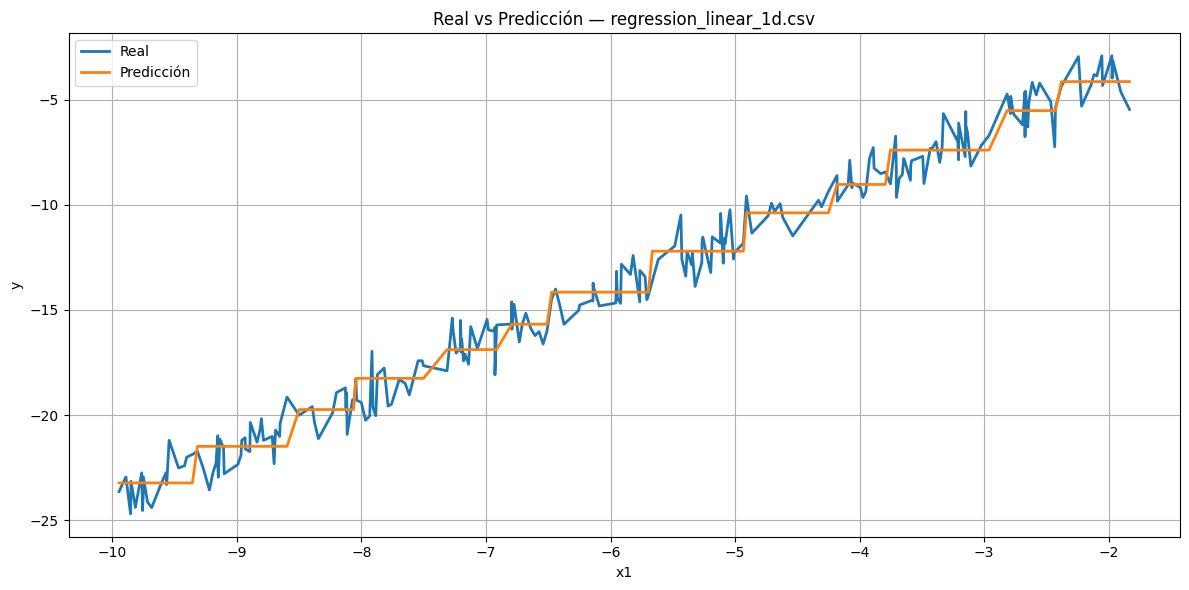

Dataset loaded: regression_polynomial_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 1.7626
MSE: 4.6166
RMSE: 2.1486
R2: 0.9888

Model Parameters
max_depth: 5
min_samples_split: 10
min_samples_leaf: 5
tree_depth_learned: 5
number_of_leaves: 32



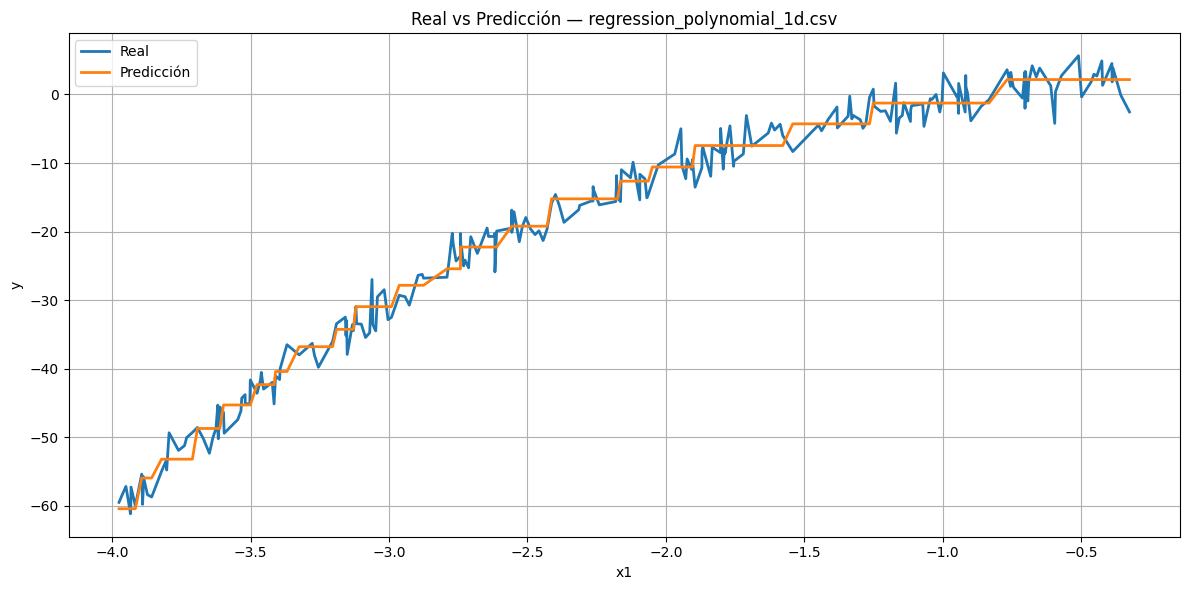

Dataset loaded: regression_sinusoidal_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 0.4995
MSE: 0.3897
RMSE: 0.6243
R2: 0.9547

Model Parameters
max_depth: 5
min_samples_split: 10
min_samples_leaf: 5
tree_depth_learned: 5
number_of_leaves: 32



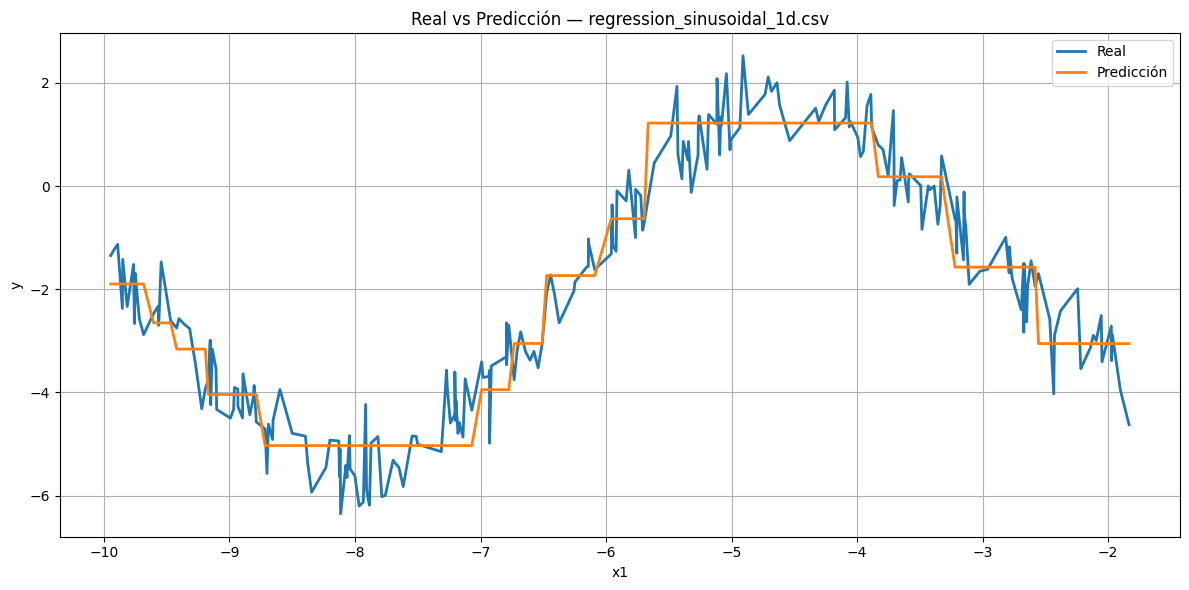

Dataset loaded: regression_piecewise_1d.csv
Shape: (3000, 2)
Input features: ['x1']

Training set: (2400, 1)
Test set: (600, 1)

Model trained successfully.

Regression Metrics
MAE: 0.6343
MSE: 0.6316
RMSE: 0.7948
R2: 0.9409

Model Parameters
max_depth: 5
min_samples_split: 10
min_samples_leaf: 5
tree_depth_learned: 5
number_of_leaves: 32



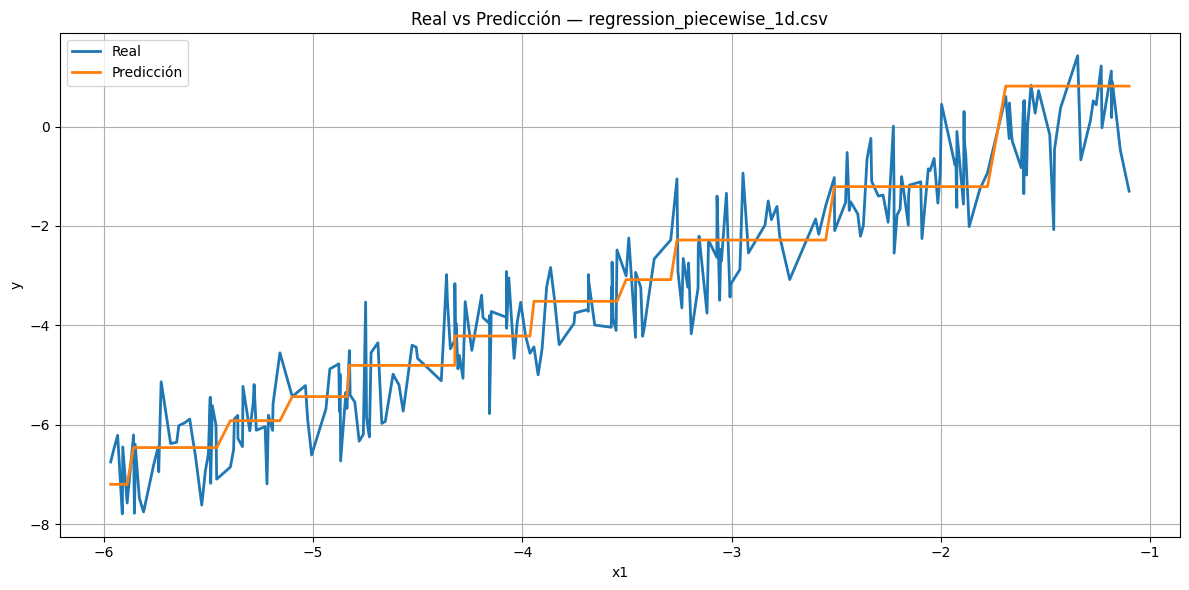

Dataset loaded: regression_interaction_2d.csv
Shape: (5000, 3)
Input features: ['x1', 'x2']

Training set: (4000, 2)
Test set: (1000, 2)

Model trained successfully.

Regression Metrics
MAE: 1.7004
MSE: 4.7622
RMSE: 2.1823
R2: 0.9373

Model Parameters
max_depth: 5
min_samples_split: 10
min_samples_leaf: 5
tree_depth_learned: 5
number_of_leaves: 32

Multi-feature dataset detected. Plotting against: x1



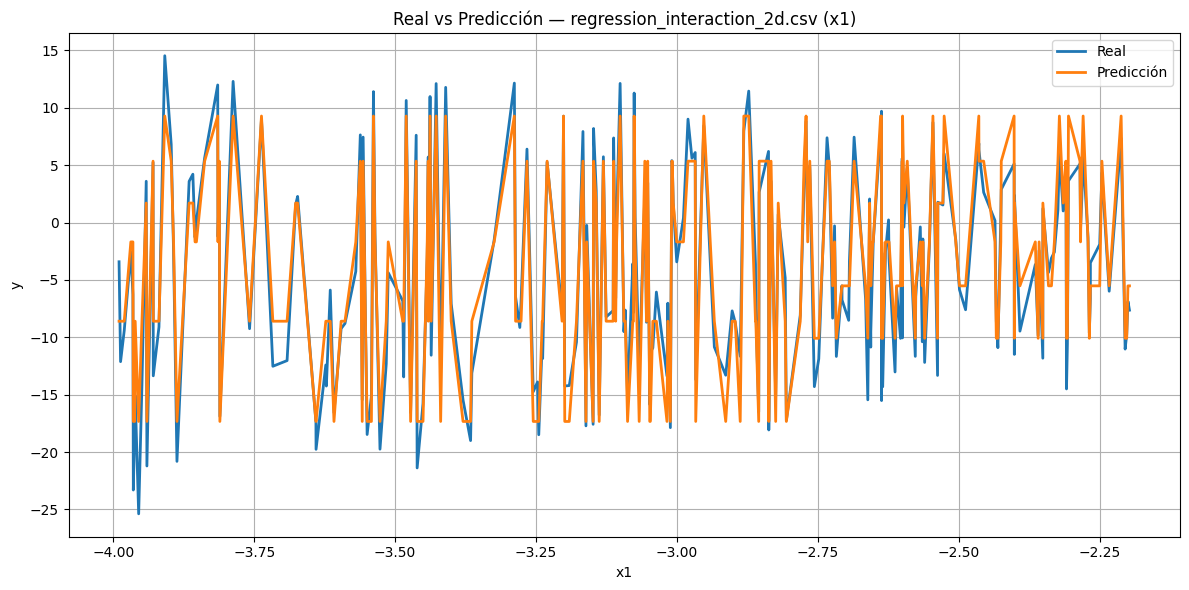

In [6]:
all_results = {}

for data_file in DATASETS:
    result = train_and_evaluate_decision_tree_regression(
        data_file=data_file,
        test_size=0.2,
        random_seed=42,
        plot_limit=250,
        sort_by_real=True,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5
    )
    all_results[data_file] = result

## Resumen de métricas

In [7]:
metrics_summary = pd.DataFrame(
    [
        {
            "dataset": data_file,
            "MAE": result["metrics"]["MAE"],
            "MSE": result["metrics"]["MSE"],
            "RMSE": result["metrics"]["RMSE"],
            "R2": result["metrics"]["R2"]
        }
        for data_file, result in all_results.items()
    ]
)

metrics_summary.sort_values(by="RMSE")

,dataset,MAE,MSE,RMSE,R2
2,regression_sinusoidal_1d.csv,0.499502,0.389692,0.624253,0.954691
3,regression_piecewise_1d.csv,0.634255,0.631632,0.794753,0.940917
0,regression_linear_1d.csv,0.750454,0.828231,0.910072,0.995983
1,regression_polynomial_1d.csv,1.762625,4.616649,2.148639,0.988777
4,regression_interaction_2d.csv,1.700394,4.762227,2.182253,0.937288


## Visualización de métricas por dataset

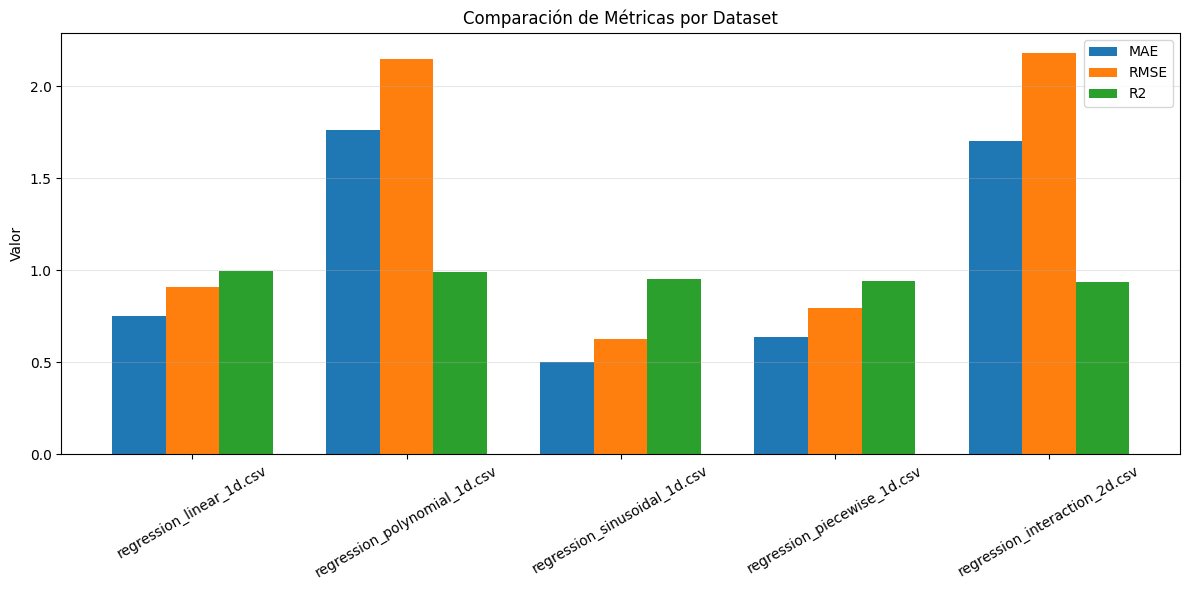

In [8]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "RMSE", "R2"]
datasets = metrics_summary["dataset"]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, metrics_summary[metric], width=width, label=metric)

plt.xticks(x + width, datasets, rotation=30)
plt.ylabel("Valor")
plt.title("Comparación de Métricas por Dataset")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Guardando Métricas

In [9]:
# Guardando métricas
metrics_summary["Model"] = "Decision Tree Regression"
metrics_summary = metrics_summary[["Model", "dataset", "MAE", "MSE", "RMSE", "R2"]]
metrics_summary.to_csv("metrics/decission_tree_regression_metrics_summary.csv", index=False)